In [1]:
## Step 1: Load Configuration and Import Libraries

import json, os, shutil, random
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

with open('/kaggle/input/notebooks/kevinchovatiya/01-kaggle-data-setup/paths_config.json') as f:
    paths = json.load(f)

DATASET_PATH_INPUT = paths['DATASET_PATH']
OUTPUT_PATH = paths['OUTPUT_PATH']

random.seed(42)
np.random.seed(42)

print(f"Input dataset: {DATASET_PATH_INPUT}")
print("✓ Libraries imported!")

Input dataset: /kaggle/input/datasets/shubhamgoel27/dermnet
✓ Libraries imported!


In [2]:
import os
import shutil
import json

# Step 2: Copy Dataset to Working Directory
DATASET_PATH_LOCAL = '/kaggle/working/dermnet_data'

if os.path.exists(DATASET_PATH_LOCAL):
    print(f"Working dataset already exists: {DATASET_PATH_LOCAL}")
else:
    print("Copying dataset to working directory...")
    print("This may take several minutes...")
    shutil.copytree(DATASET_PATH_INPUT, DATASET_PATH_LOCAL)
    print(f"✓ Copied to: {DATASET_PATH_LOCAL}")

# ✅ Update config with writable path
paths['DATASET_PATH_LOCAL'] = DATASET_PATH_LOCAL

# ✅ Save ONLY in working directory
with open('/kaggle/working/paths_config.json', 'w') as f:
    json.dump(paths, f, indent=4)

print(f"\n✓ Working dataset path: {DATASET_PATH_LOCAL}")


Copying dataset to working directory...
This may take several minutes...
✓ Copied to: /kaggle/working/dermnet_data

✓ Working dataset path: /kaggle/working/dermnet_data


In [3]:
## Step 3: Create Validation Split from Training Data

def create_validation_split(base_path, val_split=0.2):
    print(f"Creating validation split ({val_split*100:.0f}% of training data)...\n")

    train_path = os.path.join(base_path, 'train')
    val_path   = os.path.join(base_path, 'val')

    # Skip if val already exists with data
    if os.path.exists(val_path) and len(os.listdir(val_path)) > 0:
        print(f"Validation split already exists at {val_path}")
        return

    os.makedirs(val_path, exist_ok=True)
    classes = [d for d in os.listdir(train_path)
              if os.path.isdir(os.path.join(train_path, d))]

    total_moved = 0
    for class_name in tqdm(classes, desc="Processing classes"):
        class_train_path = os.path.join(train_path, class_name)
        class_val_path   = os.path.join(val_path, class_name)
        os.makedirs(class_val_path, exist_ok=True)

        images = [f for f in os.listdir(class_train_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        train_images, val_images = train_test_split(images, test_size=val_split, random_state=42)

        for img_name in val_images:
            shutil.move(
                os.path.join(class_train_path, img_name),
                os.path.join(class_val_path, img_name)
            )
            total_moved += 1

        print(f"   {class_name}: {len(train_images)} train, {len(val_images)} val")

    print(f"\n✓ Created validation set with {total_moved} images")
    print("✓ Dataset now has: train/ , val/ , test/")

create_validation_split(DATASET_PATH_LOCAL, val_split=0.2)

Creating validation split (20% of training data)...



Processing classes:   0%|          | 0/23 [00:00<?, ?it/s]

   Nail Fungus and other Nail Disease: 832 train, 208 val
   Herpes HPV and other STDs Photos: 324 train, 81 val
   Cellulitis Impetigo and other Bacterial Infections: 230 train, 58 val
   Hair Loss Photos Alopecia and other Hair Diseases: 191 train, 48 val
   Poison Ivy Photos and other Contact Dermatitis: 208 train, 52 val
   Vasculitis Photos: 332 train, 84 val
   Atopic Dermatitis Photos: 391 train, 98 val
   Melanoma Skin Cancer Nevi and Moles: 370 train, 93 val
   Scabies Lyme Disease and other Infestations and Bites: 344 train, 87 val
   Systemic Disease: 484 train, 122 val
   Vascular Tumors: 385 train, 97 val
   Acne and Rosacea Photos: 672 train, 168 val
   Exanthems and Drug Eruptions: 323 train, 81 val
   Seborrheic Keratoses and other Benign Tumors: 1096 train, 275 val
   Urticaria Hives: 169 train, 43 val
   Psoriasis pictures Lichen Planus and related diseases: 1124 train, 281 val
   Lupus and other Connective Tissue diseases: 336 train, 84 val
   Warts Molluscum and oth

In [4]:
## Step 4: Verify Split Distribution

def verify_split_distribution(base_path):
    print("\n📊 Dataset Split Distribution:\n")
    print(f"{'Class':<30} {'Train':<10} {'Val':<10} {'Test':<10} {'Total':<10}")
    print("=" * 70)

    train_path = os.path.join(base_path, 'train')
    classes = sorted([d for d in os.listdir(train_path)
                     if os.path.isdir(os.path.join(train_path, d))])

    total_train = total_val = total_test = 0

    for class_name in classes:
        counts = {}
        for split in ['train', 'val', 'test']:
            split_path = os.path.join(base_path, split, class_name)
            if os.path.exists(split_path):
                counts[split] = len([f for f in os.listdir(split_path)
                                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            else:
                counts[split] = 0
        total = sum(counts.values())
        total_train += counts['train']
        total_val   += counts['val']
        total_test  += counts['test']
        print(f"{class_name:<30} {counts['train']:<10} {counts['val']:<10} {counts['test']:<10} {total:<10}")

    print("=" * 70)
    grand_total = total_train + total_val + total_test
    print(f"{'TOTAL':<30} {total_train:<10} {total_val:<10} {total_test:<10} {grand_total:<10}")
    print(f"\n📈 Percentages:")
    print(f"   Train: {total_train/grand_total*100:.1f}%")
    print(f"   Val:   {total_val/grand_total*100:.1f}%")
    print(f"   Test:  {total_test/grand_total*100:.1f}%")

verify_split_distribution(DATASET_PATH_LOCAL)


📊 Dataset Split Distribution:

Class                          Train      Val        Test       Total     
Acne and Rosacea Photos        672        168        312        1152      
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions 919        230        288        1437      
Atopic Dermatitis Photos       391        98         123        612       
Bullous Disease Photos         358        90         113        561       
Cellulitis Impetigo and other Bacterial Infections 230        58         73         361       
Eczema Photos                  988        247        309        1544      
Exanthems and Drug Eruptions   323        81         101        505       
Hair Loss Photos Alopecia and other Hair Diseases 191        48         60         299       
Herpes HPV and other STDs Photos 324        81         102        507       
Light Diseases and Disorders of Pigmentation 454        114        143        711       
Lupus and other Connective Tissue diseases 336      

In [5]:
## Step 5: Save Dataset Metadata

def save_dataset_metadata(base_path):
    metadata = {'dataset_name': 'DermNet Skin Disease Dataset', 'splits': {}, 'classes': []}

    train_path = os.path.join(base_path, 'train')
    classes = sorted([d for d in os.listdir(train_path)
                     if os.path.isdir(os.path.join(train_path, d))])
    metadata['classes'] = classes
    metadata['num_classes'] = len(classes)

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue

        class_counts = {}
        total = 0
        for class_name in classes:
            class_path = os.path.join(split_path, class_name)
            if os.path.exists(class_path):
                count = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                class_counts[class_name] = count
                total += count
        metadata['splits'][split] = {'total_images': total, 'class_distribution': class_counts}

    output_path = os.path.join(OUTPUT_PATH, 'dataset_metadata.json')
    with open(output_path, 'w') as f:
        json.dump(metadata, f, indent=4)

    print(f"✓ Metadata saved to: {output_path}")
    return metadata

metadata = save_dataset_metadata(DATASET_PATH_LOCAL)

✓ Metadata saved to: /kaggle/working/dataset_metadata.json


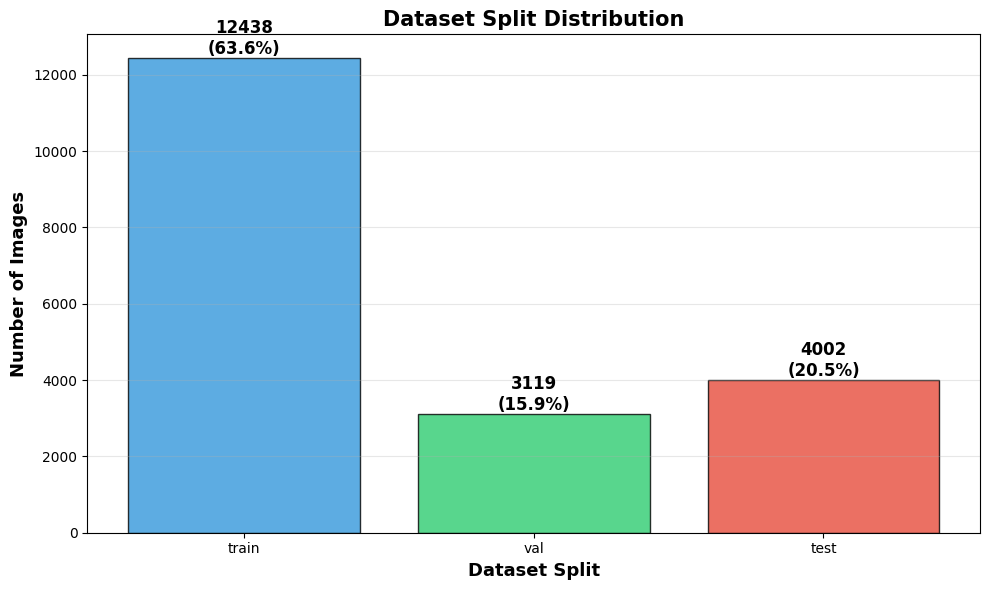

✓ Saved: /kaggle/working/split_distribution.png
✓ Config updated with DATASET_PATH_LOCAL


In [6]:
## Step 6: Visualize Split Distribution

import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']
totals = [metadata['splits'][s]['total_images'] for s in splits]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(splits, totals, color=colors, alpha=0.8, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/sum(totals)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=13, fontweight='bold')
ax.set_title('Dataset Split Distribution', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

save_path = os.path.join(OUTPUT_PATH, 'split_distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

# Update config with local dataset path
paths['DATASET_PATH_LOCAL'] = DATASET_PATH_LOCAL
with open('/kaggle/working/paths_config.json', 'w') as f:
    json.dump(paths, f, indent=4)
print("✓ Config updated with DATASET_PATH_LOCAL")

In [7]:

## Summary

##✅ Dataset copied to `/kaggle/working/dermnet_data/`  
##✅ Validation split created (80/20)  
##✅ Distribution verified  
##✅ Metadata saved